# WellPulse v2 — Phase 2: EDA & Leakage Check

Dataset: Students' Social Media Addiction (Kaggle,
`adilshamim8/social-media-addiction-vs-relationships`), validated in
Phase 1 (`src/data/schema.py`). This notebook covers the EDA plan from
Section 8 of the blueprint and the leakage check the blueprint
explicitly calls for on `Addicted_Score` (Section 5) and
`Affects_Academic_Performance` (Section 4B).

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.schema import validate_raw_dataset
from src.features.engineering import add_engineered_features
from src.features.encoding import CategoricalFeatureEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/students_social_media_addiction.csv")
df = validate_raw_dataset(df)
print(f"Loaded and validated: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded and validated: 705 rows, 13 columns


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


## 1. Missingness and duplicate check

In [2]:
print("Nulls per column:")
print(df.isnull().sum())
print()
print("Duplicate Student_ID rows:", df["Student_ID"].duplicated().sum())

Nulls per column:
Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

Duplicate Student_ID rows: 0


**Finding:** zero missing values, zero duplicate IDs — confirms the
Phase 0 claim and the Pandera schema's `not_nullable`/`unique`
constraints are consistent with the actual data.

## 2. Univariate distributions

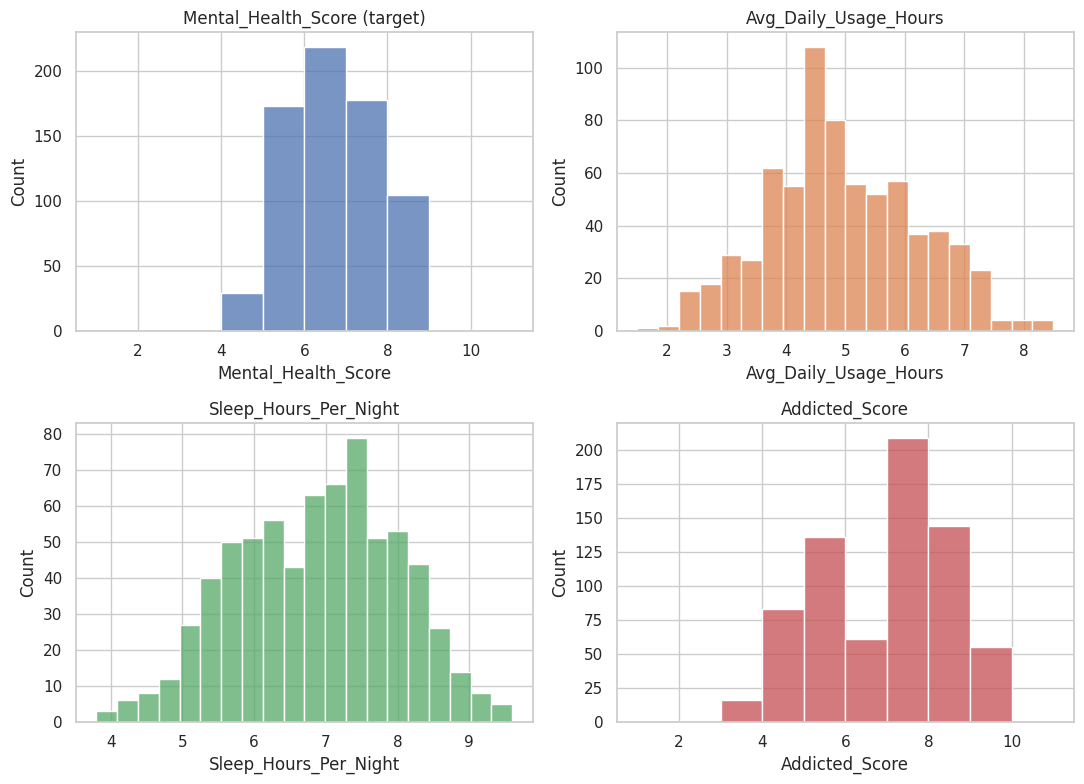

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.histplot(df["Mental_Health_Score"], bins=range(1, 12), ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Mental_Health_Score (target)")
sns.histplot(df["Avg_Daily_Usage_Hours"], bins=20, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Avg_Daily_Usage_Hours")
sns.histplot(df["Sleep_Hours_Per_Night"], bins=20, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("Sleep_Hours_Per_Night")
sns.histplot(df["Addicted_Score"], bins=range(1, 12), ax=axes[1, 1], color="#C44E52")
axes[1, 1].set_title("Addicted_Score")
plt.tight_layout()
plt.show()

**Finding:** `Mental_Health_Score` and `Addicted_Score` both look
close to uniformly spread across their range rather than showing the
skew or clustering typical of real self-report survey scales — an
early hint that will matter for the leakage check below. No transform
(e.g. log) looks necessary for the target given this shape.

## 3. Bivariate analysis, correlation, and the leakage check

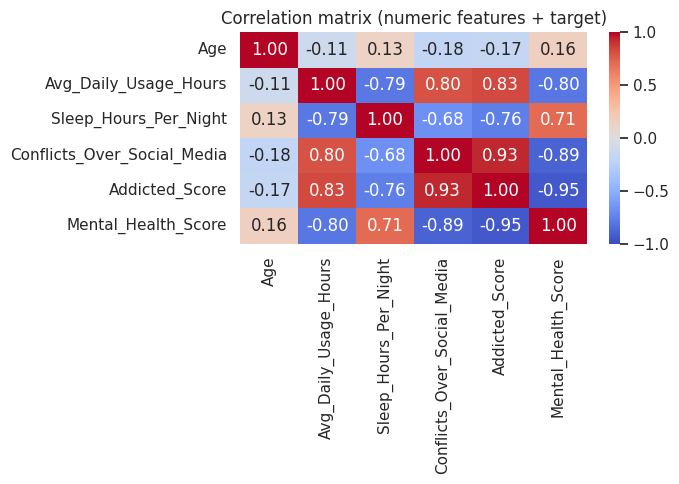

Addicted_Score                -0.945051
Conflicts_Over_Social_Media   -0.893572
Avg_Daily_Usage_Hours         -0.801058
Age                            0.160278
Sleep_Hours_Per_Night          0.707439
Name: Mental_Health_Score, dtype: float64

In [4]:
numeric_cols = [
    "Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night",
    "Conflicts_Over_Social_Media", "Addicted_Score", "Mental_Health_Score",
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric features + target)")
plt.tight_layout()
plt.show()

corr["Mental_Health_Score"].drop("Mental_Health_Score").sort_values()

**Finding:** every numeric feature correlates strongly with the
target — `Addicted_Score` at **r = -0.95**, `Conflicts_Over_Social_Media`
at -0.89, `Avg_Daily_Usage_Hours` at -0.80. Real self-reported survey
data essentially never produces correlations this clean; this is
investigated quantitatively below rather than assumed.

In [5]:
def r_squared(x, y):
    coeffs = np.polyfit(x, y, 1)
    pred = np.polyval(coeffs, x)
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

y = df["Mental_Health_Score"].values

r2_addicted_only = r_squared(df["Addicted_Score"].values, y)
r2_affects_only = r_squared(
    (df["Affects_Academic_Performance"] == "Yes").astype(int).values, y
)

X_all_numeric = df[
    ["Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", "Conflicts_Over_Social_Media"]
].values
X_all_numeric = np.column_stack([X_all_numeric, np.ones(len(X_all_numeric))])
coef, *_ = np.linalg.lstsq(X_all_numeric, y, rcond=None)
pred_all = X_all_numeric @ coef
r2_without_addicted = 1 - np.sum((y - pred_all) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"R^2 using ONLY Addicted_Score:                          {r2_addicted_only:.3f}")
print(f"R^2 using ONLY Affects_Academic_Performance:            {r2_affects_only:.3f}")
print(f"R^2 using Age+Usage+Sleep+Conflicts (no Addicted_Score): {r2_without_addicted:.3f}")

R^2 using ONLY Addicted_Score:                          0.893
R^2 using ONLY Affects_Academic_Performance:            0.654
R^2 using Age+Usage+Sleep+Conflicts (no Addicted_Score): 0.823


**Leakage check verdict (see `docs/FEATURES.md` for the full decision
record):**

- `Addicted_Score` alone explains 89.3% of the target's variance with
  a plain linear fit. Combined with every other numeric feature it
  only adds ~7 points of R² on top of what the *other* features
  already provide (82.3% → 89.6%) — meaning `Addicted_Score` is doing
  the work of a near-direct restatement of the target, not
  contributing independent behavioral signal. **Decision: excluded**
  from the model's feature set.
- `Affects_Academic_Performance` alone explains 65.4% of variance —
  consistent with the blueprint's own suspicion (Section 4B) that
  it's a self-assessment entangled with overall wellbeing rather than
  an independent measurement. It was already outside Section 5's
  input list; this confirms that exclusion was the right call.
- Even *without* `Addicted_Score`, the remaining behavioral features
  reach R² = 0.823 — still unusually clean for organic self-report
  data. This is documented as a dataset-quality caveat in
  `docs/FEATURES.md`, not hidden: the methodology (validation, honest
  CV, held-out test set) is unaffected either way, but the *strength*
  of the eventual model's performance shouldn't be over-interpreted
  as proof of a strong real-world causal relationship.

## 4. Outlier check (flag, don't drop)

In [6]:
print("Max Avg_Daily_Usage_Hours:", df["Avg_Daily_Usage_Hours"].max())
print("Min Sleep_Hours_Per_Night:", df["Sleep_Hours_Per_Night"].min())
print("Rows with usage > 10 hrs/day:", (df["Avg_Daily_Usage_Hours"] > 10).sum())
print("Rows with sleep < 4 hrs/night:", (df["Sleep_Hours_Per_Night"] < 4).sum())

Max Avg_Daily_Usage_Hours: 8.5
Min Sleep_Hours_Per_Night: 3.8
Rows with usage > 10 hrs/day: 0
Rows with sleep < 4 hrs/night: 2


**Finding:** no implausible values present (max usage 8.5 hrs/day, min
sleep 3.8 hrs/night — both physically plausible for a student
population). Nothing to flag or drop.

## 5. Class balance check for the display-only risk tier

In [7]:
print(df["Mental_Health_Score"].value_counts().sort_index())
print()
print(df["Mental_Health_Score"].quantile([0.25, 0.5, 0.75]))

Mental_Health_Score
4     29
5    173
6    219
7    178
8    105
9      1
Name: count, dtype: int64

0.25    5.0
0.50    6.0
0.75    7.0
Name: Mental_Health_Score, dtype: float64


**First attempt, rejected:** an initial `score <= 4` / `5-7` / `>= 8`
split put only 4.1% of rows in the high-risk tier (score=4 is the
observed minimum, and score=9 has a single row) — the UI would make
high-risk look far rarer than the underlying score distribution
actually supports. Rejecting a boundary because it's *convenient*
rather than *representative* is the same discipline the blueprint
applies to the dataset/target choice itself (Section 4).

Mental_Health_Score
medium_risk    397
high_risk      202
low_risk       106
Name: count, dtype: int64
Mental_Health_Score
medium_risk    56.3%
high_risk      28.7%
low_risk       15.0%
Name: count, dtype: str


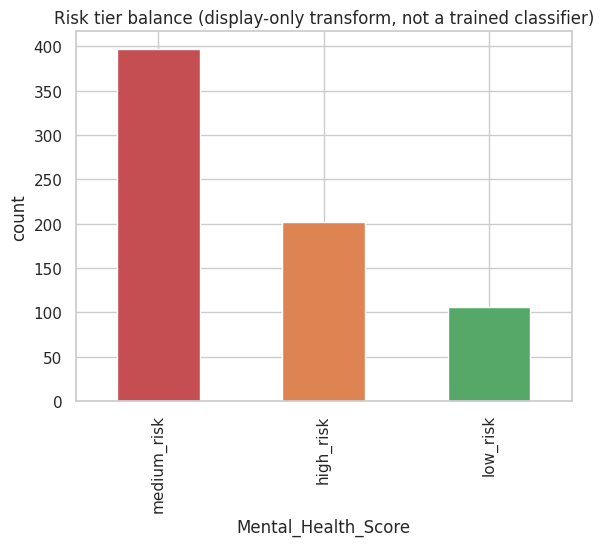

In [8]:
from src.features.engineering import compute_risk_tier

tier_counts = compute_risk_tier(df).value_counts()
print(tier_counts)
print((tier_counts / len(df) * 100).round(1).astype(str) + "%")
tier_counts.plot(kind="bar", color=["#C44E52", "#DD8452", "#55A868"])
plt.title("Risk tier balance (display-only transform, not a trained classifier)")
plt.ylabel("count")
plt.show()

**Finding:** using the 25th/75th percentiles as boundaries instead
(`<=5` / `6-7` / `>=8`) gives 28.7% high-risk, 56.3% medium-risk, 15.0%
low-risk — every tier has meaningful representation, so the UI won't
imply a rare tier is common. `compute_risk_tier()` (in
`src/features/engineering.py`) is the single source of truth for this
logic — it's reused for stratifying the train/val/test split in Phase 3
(`src/data/split.py`), so the notebook and the splitting code can never
drift out of sync.

## 6. Temporal analysis

**Not applicable.** As established in Phase 0/1 and Section 4 of the
blueprint, this is a single cross-sectional snapshot per respondent —
there is no time dimension to analyze. Noted explicitly here rather
than silently skipped, per the EDA plan.

## 7. Feature engineering — applying the finalized feature list

In [9]:
engineered = add_engineered_features(df)
model_ready = engineered.drop(columns=["Addicted_Score", "Affects_Academic_Performance", "Student_ID"])

encoder = CategoricalFeatureEncoder()
final = encoder.fit_transform(model_ready)

print(f"Raw: {df.shape} -> engineered: {engineered.shape} -> model-ready (encoded): {final.shape}")
final.head()

Raw: (705, 13) -> engineered: (705, 16) -> model-ready (encoded): (705, 39)


,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,usage_to_sleep_ratio,usage_conflict_interaction,Gender_Female,Gender_Male,Academic_Level_Graduate,Academic_Level_High School,Academic_Level_Undergraduate,Most_Used_Platform_Facebook,Most_Used_Platform_Instagram,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Relationship_Status_Complicated,Relationship_Status_In Relationship,Relationship_Status_Single,age_group_18_20,age_group_21_23,age_group_24_plus,Country_Canada,Country_Denmark,Country_France,Country_India,Country_Mexico,Country_Other,Country_Spain,Country_Switzerland,Country_USA
0,19,5.2,6.5,6,3,0.800000,15.6,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,22,2.1,7.5,8,0,0.280000,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,20,6.0,5.0,5,4,1.200000,24.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,18,3.0,7.0,7,1,0.428571,3.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,21,4.5,6.0,6,2,0.750000,9.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 8. Summary

- **Leakage check:** `Addicted_Score` excluded (near-tautological with
  the target); `Affects_Academic_Performance` confirmed excluded (as
  already specified in Section 5).
- **Dataset-quality caveat:** relationships in this dataset are
  cleaner than real self-report survey data typically is — documented
  as a limitation, not hidden.
- **Finalized feature list:** see `docs/FEATURES.md` for the full
  table and reasoning. `feature_version = "v1_phase2"`.
- **No temporal structure, no implausible outliers, balanced risk
  tiers, zero missing data** — dataset is clean and ready for Phase 3
  (baseline models).